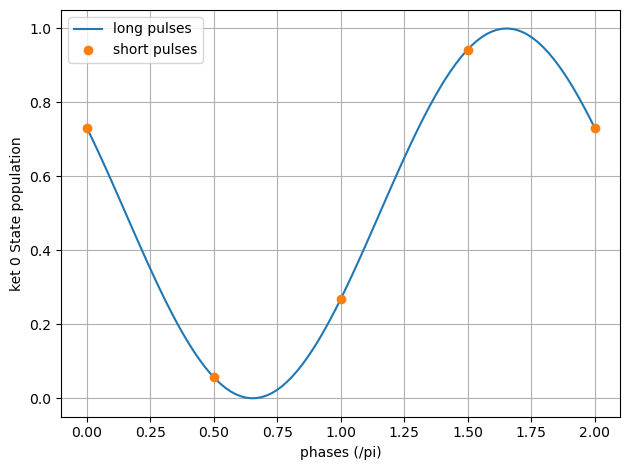

In [2]:
import numpy as np
from scipy.linalg import expm
import io
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs
    
def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals


def B_line_mG(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    return (
        B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
        - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
    ) * 1e-3

def primitive_B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    t_arr_1d = np.atleast_1d(t_arr)
    omega = 2.0 * np.pi * freqs

    B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
    const_term = (B0_use - B_line_0) * t_arr_1d
    sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

    F_mG = const_term + np.sum(sin_terms, axis=0)
    F_Gs = 1e-3 * F_mG
    if np.isscalar(t):
        return float(F_Gs[0])
    return F_Gs

def integral_B_rel_G(t_start, t_end, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
    F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
    return F_end - F_start

def get_pulse_schedule(rabi_freqs, fractions):
    if len(rabi_freqs) != len(fractions):
        raise ValueError(
            f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
        )
    times = []
    t_current = 0.0
    for Omega, frac in zip(rabi_freqs, fractions):
        if not 0 <= frac <= 1:
            raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        theta = 2.0 * np.arcsin(np.sqrt(frac))
        t_pulse = theta / Omega if Omega > 0 else 0.0
        t_start = t_current
        t_end = t_current + t_pulse
        times.append((t_start, t_end))
        t_current = t_end
    return times

def compute_pi_times(pi_t = [26.374, 38.265, 118.144, 30.527, 38.734]):
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt"
    transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
    transition_strengths[transition_strengths == 0] = np.nan
    strengths = np.array(
        [
            transition_strengths[21, 2],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4],
        ]
    )
    factors = np.array(pi_t, dtype=float) * strengths

    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros((24, 5), dtype=float)
    for i in range(transition_strengths.shape[0]):
        for j in range(transition_strengths.shape[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times

def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out

def bussed_ramsey_pop0(transition_pair, T, delta, ramsey_phase,  pi_time_refs = [26.374, 38.265, 118.144, 30.527, 38.734], consider_line = False):
    # get sensitivity table
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p209.txt" 
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(transition_pair, sens_matrix)
    #get - pitimes
    pi_times = get_pi_times_from_matrix(transition_pair, compute_pi_times(pi_t = pi_time_refs))
    #get - sensitivities
    pair_sensitivities = get_pi_times_from_matrix(transition_pair, sens_matrix)

    pi_time_0b = pi_times[0]
    pi_time_b1 = pi_times[1]
    sens_0b = pair_sensitivities[0]
    sens_b1 = pair_sensitivities[1]
    # Rabi frequencies
    omega_0b = np.pi / (pi_time_0b * 1e-6)
    omega_b1 = np.pi / (pi_time_b1 * 1e-6)
    omega_dummy = np.pi/(1)
    t_pi2_0b = (pi_time_0b * 1e-6) / 2
    t_pi_b1 = (pi_time_b1 * 1e-6)

    Ramsey_wait = T * 1e-6
    # get - integral_values
    fractions = [1, 0.5, (np.sin((T/1e6)*(np.pi/2)))**2, 0.5, 1]
    rabi_freqs = [omega_0b, omega_b1, omega_dummy, omega_b1, omega_0b]
    times_seq_for_integral = get_pulse_schedule(rabi_freqs, fractions)
    # print(times_seq_for_integral)
    line_int_values = []
    for slots in times_seq_for_integral:
        if  consider_line:
            line_int_values.append(2.0 * np.pi * 1e6*integral_B_rel_G(slots[0], slots[1]))
        else:
            line_int_values.append(0)
    # print(line_int_values)

    def U_0b(omega, t, phase, delta, line_delta_eq = 0):
        H = np.array([
            [0, omega * np.exp(-1j * phase) / 2, 0],
            [omega * np.exp(1j * phase) / 2, -(delta - (sens_0b*line_delta_eq/t)), 0],
            [0, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    def U_b1(omega, t, phase, delta, line_delta_eq = 0):
        H = np.array([
            [0, 0, omega * np.exp(-1j * phase) / 2],
            [0, -(delta - (sens_0b*line_delta_eq/t)), 0],
            [omega * np.exp(1j * phase) / 2, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    def U_wait(t, delta, line_delta_eq = 0):
        H = np.array([
            [0, 0, 0],
            [0, -(  delta - (sens_0b*line_delta_eq/t)), 0],
            [0, 0, -(sens_b1*line_delta_eq/t)]
        ], dtype=complex)
        return expm(-1j * H * t)

    # --- Pulse sequence ---
    U1 = U_0b(omega_0b, t_pi2_0b, phase=np.pi, delta=delta, line_delta_eq = line_int_values[0])
    U2 = U_b1(omega_b1, t_pi_b1, phase=0, delta = delta, line_delta_eq = line_int_values[1])
    Uw = U_wait(Ramsey_wait, delta, line_delta_eq = line_int_values[2])
    U3 = U_b1(omega_b1, t_pi_b1, phase=np.pi, delta = delta, line_delta_eq = line_int_values[3])
    U4 = U_0b(omega_0b, t_pi2_0b, phase=np.pi*ramsey_phase, delta=delta, line_delta_eq = line_int_values[4])

    U_total = U4 @ U3 @ Uw @ U2 @ U1

    # Initial state |0>
    ket0 = np.array([0, 1, 0], dtype=complex)

    final_state = U_total @ ket0
    pop0 = np.abs(final_state[1])**2

    return pop0

plt.figure()
phases = np.linspace(0, 2, 100)
pops_list = []
det =  -2*np.pi*72
wait_time = 1000
for ph in phases:
    pops_list.append(bussed_ramsey_pop0([[0, 3, 1], [0, 2, 0]], wait_time, det, ph, pi_time_refs = [24.17, 38.265, 102.1, 30.527, 38.734], consider_line = True))


pops_list = np.array(pops_list)
# display(pops_list)
plt.plot(phases, pops_list, label = 'long pulses')

det =  -2*np.pi*72
wait_time = 1000
phase_list = [0, 0.5, 1, 1.5, 2]
ket_data = []
for ph in phase_list:
    ket_data.append(bussed_ramsey_pop0([[0, 3, 1], [0, 2, 0]], wait_time, det, ph, pi_time_refs = [24.17, 38.265, 102.1, 30.527, 38.734], consider_line = True))


plt.plot(phase_list, ket_data, 'o', label = 'short pulses')
plt.xlabel('phases (/pi)')
plt.ylabel('ket 0 State population')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
%matplotlib widget

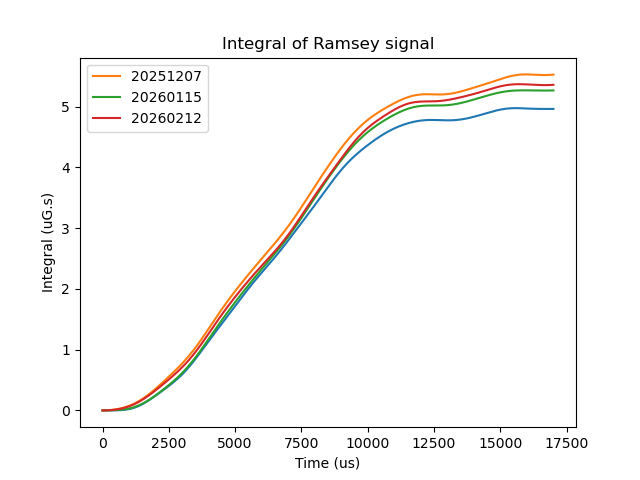

4.973402796063482


In [4]:
# import n
times  =  np.linspace(0, 17000*1e-6, 200)
ints = []
ints_20251207 = []
ints_20260115 = []
ints_20260212 = []
for i in times:
    ints.append(integral_B_rel_G(0, i)*1e6)
    ints_20251207.append(integral_B_rel_G(0, i, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20251207.txt')*1e6)
    ints_20260115.append(integral_B_rel_G(0, i, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260115.txt')*1e6)
    ints_20260212.append(integral_B_rel_G(0, i, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260212.txt')*1e6)

plt.plot(times*1e6, ints)
plt.plot(times*1e6, ints_20251207, label = '20251207')
plt.plot(times*1e6, ints_20260115, label = '20260115')
plt.plot(times*1e6, ints_20260212, label = '20260212')
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Integral (uG.s)')
plt.title('Integral of Ramsey signal')
plt.show()
print(max(ints))

In [5]:
(max(ints_20260115) - max(ints_20260212))*3.4

-0.3435660351170973

In [6]:
0.0006935556896966499 * 3.42* 2

0.004743920917525086

-17.72449530409368


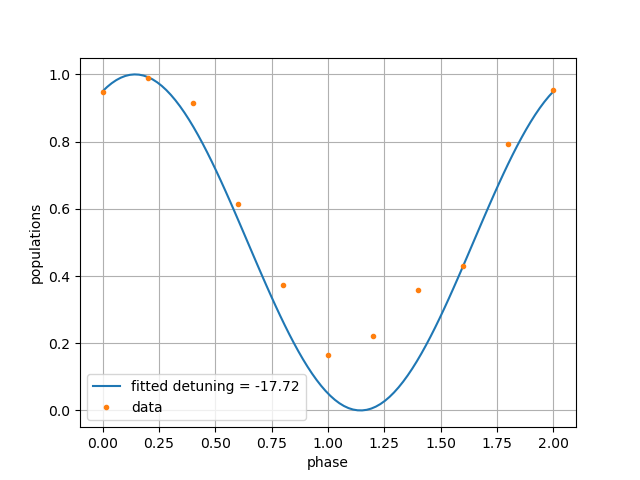

In [8]:
from scipy.optimize import curve_fit

def fit_detuning_for_one_dataset(ket_data,
                                 phase_list,
                                 transition_pair,
                                 T_wait_bussed_ramsey,
                                 pi_time_refs =  [26, 38.265, 118, 30.527, 38.734],
                                 initial_delta_guess=-2 * np.pi * 0, consider_line = True):
    ket_data = np.array(ket_data, dtype=float)

    phase_array = np.array(phase_list, dtype=float)

    if ket_data.shape[0] != phase_array.shape[0]:
        raise ValueError("ket_data and phase_list must have the same length.")



    def ramsey_model(phase_pi, delta):
        return np.array([
            bussed_ramsey_pop0(transition_pair, T_wait_bussed_ramsey, delta, ph, consider_line = True, pi_time_refs = pi_time_refs)
            for ph in phase_pi
        ])

    try:
        params, covariance = curve_fit(
            ramsey_model,
            phase_array,
            ket_data,
            p0=[initial_delta_guess],

            maxfev=5000
        )
        delta_opt = params[0]
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            delta_err = errors[0] if np.isfinite(errors[0]) else None
        else:
            delta_err = None
        return delta_opt, delta_err
    except RuntimeError:
        return None, None

ket_data = [np.float64(0.1958762886597938), np.float64(0.07291666666666667), np.float64(0.052083333333333336), np.float64(0.24210526315789474), np.float64(0.5578947368421052), np.float64(0.8645833333333334), np.float64(0.968421052631579), np.float64(0.9583333333333334), np.float64(0.6354166666666666), np.float64(0.3469387755102041), np.float64(0.15463917525773196)]
ket_data = [np.float64(0.24210526315789474), np.float64(0.02040816326530612), np.float64(0.1717171717171717), np.float64(0.3541666666666667), np.float64(0.8673469387755102), np.float64(0.9896907216494846), np.float64(0.8947368421052632), np.float64(0.494949494949495), np.float64(0.35714285714285715), np.float64(0.16), np.float64(0.020833333333333332)]
ket_data = [np.float64(0.3838383838383838), np.float64(0.09183673469387756), np.float64(0.030927835051546393), np.float64(0.07142857142857142), np.float64(0.26804123711340205), np.float64(0.5773195876288659), np.float64(0.83), np.float64(0.9595959595959596), np.float64(0.94), np.float64(0.6868686868686869), np.float64(0.425531914893617)]

ket_data = [np.float64(0.7096774193548387), np.float64(0.42105263157894735), np.float64(0.11224489795918367), np.float64(0.02040816326530612), np.float64(0.08163265306122448), np.float64(0.16494845360824742), np.float64(0.3958333333333333), np.float64(0.6458333333333334), np.float64(0.8686868686868687), np.float64(0.7676767676767676), np.float64(0.9292929292929293)]
ket_data = [np.float64(0.7777777777777778), np.float64(0.6129032258064516), np.float64(0.32558139534883723), np.float64(0.2), np.float64(0.052083333333333336), np.float64(0.041666666666666664), np.float64(0.23958333333333334), np.float64(0.5684210526315789), np.float64(0.7659574468085106), np.float64(0.8924731182795699), np.float64(0.875)]
ket_data = [np.float64(0.4731182795698925), np.float64(0.2127659574468085), np.float64(0.03333333333333333), np.float64(0.03296703296703297), np.float64(0.2391304347826087), np.float64(0.3626373626373626), np.float64(0.5670103092783505), np.float64(0.7916666666666666), np.float64(0.8602150537634409), np.float64(0.6947368421052632), np.float64(0.4)]
#ket_data =  [np.float64(0.4111111111111111), np.float64(0.18085106382978725), np.float64(0.020618556701030927), np.float64(0.06451612903225806), np.float64(0.18181818181818182), np.float64(0.5), np.float64(0.7303370786516854), np.float64(0.8315789473684211), np.float64(0.7528089887640449), np.float64(0.6288659793814433), np.float64(0.3118279569892473)]
 
#ket_data = [np.float64(0.776595744680851), np.float64(0.8421052631578947), np.float64(0.7473684210526316), np.float64(0.6979166666666666), np.float64(0.3473684210526316), np.float64(0.07368421052631578), np.float64(0.02040816326530612), np.float64(0.07368421052631578), np.float64(0.2127659574468085), np.float64(0.5851063829787234), np.float64(0.8541666666666666)]
ket_data = [np.float64(0.5376344086021505),  np.float64(0.8315789473684211), np.float64(0.5257731958762887)]
# detuning = -50 Hz 20260211_1415 T = 5000
ket_data = [np.float64(0.9081632653061225), np.float64(0.723404255319149), np.float64(0.6105263157894737), np.float64(0.31313131313131315), np.float64(0.0707070707070707), np.float64(0.031578947368421054), np.float64(0.12244897959183673), np.float64(0.23958333333333334), np.float64(0.648936170212766), np.float64(0.8709677419354839), np.float64(0.8979591836734694)]
# # detuning = -50 Hz 20260211_1416 T = 2500
# ket_data = [np.float64(0.2755102040816326), np.float64(0.020618556701030927), np.float64(0.050505050505050504), np.float64(0.1836734693877551), np.float64(0.40404040404040403), np.float64(0.7628865979381443), np.float64(0.9081632653061225), np.float64(0.89), np.float64(0.7395833333333334), np.float64(0.5360824742268041), np.float64(0.20202020202020202)]
# # detuning = 0 Hz 20260211_1417 T = 2500
# ket_data = [np.float64(0.0425531914893617), np.float64(0.011494252873563218), np.float64(0.22340425531914893), np.float64(0.47474747474747475), np.float64(0.631578947368421), np.float64(0.7528089887640449), np.float64(0.8152173913043478), np.float64(0.5869565217391305), np.float64(0.3854166666666667), np.float64(0.14736842105263157), np.float64(0.011111111111111112)]
# detuning = 0 Hz 20260211_1417 T = 5000
ket_data = [np.float64(0.25), np.float64(0.15555555555555556), np.float64(0.041237113402061855), np.float64(0.07692307692307693), np.float64(0.17708333333333334), np.float64(0.3695652173913043), np.float64(0.5806451612903226), np.float64(0.782608695652174), np.float64(0.7849462365591398), np.float64(0.6736842105263158), np.float64(0.4838709677419355)]
# #detuning = -150 Hz 1455 T = 2500
# ket_data = [np.float64(0.7604166666666666), np.float64(0.6413043478260869), np.float64(0.5567010309278351), np.float64(0.21505376344086022), np.float64(0.061855670103092786), np.float64(0.022727272727272728), np.float64(0.25), np.float64(0.44565217391304346), np.float64(0.6774193548387096), np.float64(0.8229166666666666), np.float64(0.7419354838709677)]
# #detuning = -150 Hz 1455 T = 5000
# ket_data = [np.float64(0.02127659574468085), np.float64(0.0425531914893617), np.float64(0.20652173913043478), np.float64(0.4), np.float64(0.5979381443298969), np.float64(0.8064516129032258), np.float64(0.7446808510638298), np.float64(0.6382978723404256), np.float64(0.4574468085106383), np.float64(0.1978021978021978), np.float64(0.05434782608695652)]
# # #detuning = -100 T = 2500
# # ket_data = [np.float64(0.5918367346938775), np.float64(0.36363636363636365), np.float64(0.1958762886597938), np.float64(0.031578947368421054), np.float64(0.11578947368421053), np.float64(0.34375), np.float64(0.7346938775510204), np.float64(0.8469387755102041), np.float64(0.9489795918367347), np.float64(0.8762886597938144), np.float64(0.7272727272727273)]
# #detuning = -200 T = 2500

# ket_data = [np.float64(0.8247422680412371), np.float64(0.9285714285714286), np.float64(0.7959183673469388), np.float64(0.5876288659793815), np.float64(0.2736842105263158), np.float64(0.10204081632653061), np.float64(0.01020408163265306), np.float64(0.10416666666666667), np.float64(0.30434782608695654), np.float64(0.6185567010309279), np.float64(0.8152173913043478)]

# #detuning = -250 T = 2500
# ket_data = [np.float64(0.5319148936170213), np.float64(0.7894736842105263), np.float64(0.8241758241758241), np.float64(0.7553191489361702), np.float64(0.6344086021505376), np.float64(0.23404255319148937), np.float64(0.07446808510638298), np.float64(0.010416666666666666), np.float64(0.06382978723404255), np.float64(0.23157894736842105), np.float64(0.5913978494623656)]
# phase_list = np.linspace(0, 2, 11)

# #detuing = -250 T = 1500

# ket_data = [np.float64(0.875), np.float64(0.59375), np.float64(0.34444444444444444), np.float64(0.10526315789473684), np.float64(0.021052631578947368), np.float64(0.06382978723404255), np.float64(0.2087912087912088), np.float64(0.4421052631578947), np.float64(0.711340206185567), np.float64(0.8854166666666666), np.float64(0.84375)]

ket_data = [np.float64(0.05102040816326531), np.float64(0.01098901098901099), np.float64(0.0851063829787234), np.float64(0.38636363636363635), np.float64(0.627906976744186), np.float64(0.8351648351648352), np.float64(0.7789473684210526), np.float64(0.6404494382022472), np.float64(0.5714285714285714), np.float64(0.20652173913043478), np.float64(0.046511627906976744)]

ket_data = 1-np.array(ket_data)

phase_list = np.linspace(0, 2, 11)
# phase_list = np.array([ 0.6,  1. ,  1.4, ])
wait_time = 4572
fitted_det  , fitted_det_err = fit_detuning_for_one_dataset(ket_data, phase_list, [[0, 3, -1], [0, 2, 0]], wait_time, pi_time_refs = [21.74, 30.63, 94.6, 24.625, 33.466], consider_line = True)
# [26.37, 38.265, 118.1438, 30.527, 38.734]
print(fitted_det/(2*np.pi))

# print(fitted_det_err/(2*np.pi))

det =  -2*np.pi*28#fitted_det
phases = np.linspace(0, 2, 100)
pops_list = []
for ph in phases:
    pops_list.append(bussed_ramsey_pop0([[0, 3, -1], [0, 2, 0]], wait_time, fitted_det, ph, pi_time_refs = [21.74, 30.63, 94.6, 24.625, 33.466], consider_line = True))
plt.figure()
plt.plot(phases, pops_list, label = f'fitted detuning = {np.round(fitted_det/(2*np.pi), 2)}')
plt.plot(phase_list, ket_data, '.', label = 'data')
plt.xlabel('phase')
plt.ylabel('populations')
plt.grid()
plt.legend()
plt.show()



In [140]:
phase_list = np.linspace(0, 2, 11)
display(phase_list)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ])

In [190]:
x = [[0, 4, -2]]

if x[0] == [0, 4, -2]:
    print(True)

True


# Data Analysis


In [131]:
sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p209.txt" 
sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
sens_list = get_pi_times_from_matrix([[0, 4, 1], [0, 2, 0]], compute_pi_times(pi_t = [1e-6]*5))
print(sens_list)

[np.float64(3.945613892465771e-06), np.float64(1e-06)]


In [3]:
# Cell 1: Load transition→datetimes from log, then build wait_time_list + raw_file_paths_list
import os
import re
from datetime import datetime
from collections import defaultdict
import io
# -----------------------
# User configuration
# -----------------------
# directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
# Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file

directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
log_path = r'bussed_ramsey_calibration_data_check.txt'
log_path = r'Checks_after_bussed_calibrations.txt'
directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Bussed_ramsey_detuning_calibration_data\\'

# Choose ONE transition pair for this notebook run (edit these)
target_transitions = [[2, 4, 2], [2, 3, 0]]  # [[m,F,mF],[m,F,mF]]

# -----------------------
# Helpers (Cell 1)
# -----------------------
def parse_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\],\s*"
        r"\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\]\]_(\d+(?:\.\d+)?)_us_(\d+)_"
        r"(\d{8})_(\d{4})"
    )
    match = re.search(pattern, filename)
    if match:
        m1  = int(match.group(1))
        F1  = int(match.group(2))
        mF1 = int(match.group(3))
        m2  = int(match.group(4))
        F2  = int(match.group(5))
        mF2 = int(match.group(6))

        wait_time = float(match.group(7))   # e.g. 16800.1
        comp_flag = int(match.group(8))     # e.g. 0 or 1

        date_str = match.group(9) + match.group(10)  # "YYYYMMDDHHMM"
        date_time = datetime.strptime(date_str, '%Y%m%d%H%M')

        transitions = [(m1, F1, mF1), (m2, F2, mF2)]
        return transitions, wait_time, date_time, comp_flag
    else:
        return None, None, None, None

def extract_raw_data_filenames(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    raw_data_filenames_line = lines[-1].strip()
    raw_data_filenames = [
        name.strip().strip("'\"") for name in raw_data_filenames_line.strip('[]').split(',')
    ]
    return raw_data_filenames

def search_files_by_transitions(directory, target_transitions, target_date_times=None):
    """
    target_transitions: list like [[0, 2, 0], [0, 4, -2]]
    target_date_times: set(datetime) or None
    """
    target_transitions = [tuple(t) for t in target_transitions]

    wait_time_list = []
    raw_file_paths_list = []
    final_transitions = None

    for filename in os.listdir(directory):
        if filename.startswith('Ramsey_experiment'):
            transitions, wait_time, date_time, comp_flag = parse_filename(filename)
            if transitions is None or wait_time is None or date_time is None:
                continue

            # exact match of the two transitions (order matters)
            if transitions == target_transitions:
                if target_date_times and date_time not in target_date_times:
                    continue

                final_transitions = transitions
                file_path = os.path.join(directory, filename)

                raw_data_filenames = extract_raw_data_filenames(file_path)
                raw_data_filepaths = [
                    os.path.join(Z_drive_raw_data, raw_filename)
                    for raw_filename in raw_data_filenames
                ]

                wait_time_list.append(wait_time)
                raw_file_paths_list.append(raw_data_filepaths)

    return wait_time_list, raw_file_paths_list, final_transitions

def parse_log_file_for_pair(log_path, target_transitions):
    """
    Reads your log text file and returns a set(datetime) for a single transition pair.
    Expects lines like:
      [[0, 4, -1], [0, 2, 0]], 0, 0, 0, ['20260122_2001', '20260122_2106']
    """
    # Normalize target to tuple-of-tuples
    tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))

    # Capture the two [a,b,c] blocks and the final list of quoted datetimes
    line_re = re.compile(
        r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
        r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,.*?,\s*"
        r"\[(.*?)\]\s*$"
    )

    dt_set = set()

    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            m = line_re.match(line)
            if not m:
                continue

            p1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
            p2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
            key = (p1, p2)
            if key != tkey:
                continue

            dates_blob = m.group(7).strip()
            date_tokens = re.findall(r"['\"](\d{8}_\d{4})['\"]", dates_blob)
            for tok in date_tokens:
                dt_set.add(datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M"))

    return dt_set

# -----------------------
# Run Cell 1
# -----------------------
target_transitions = [[0, 3, 0], [0, 2, 0]]
target_date_times = parse_log_file_for_pair(log_path, target_transitions)
if len(target_date_times) == 0:
    raise ValueError(f"No datetimes found in log for transition pair: {target_transitions}")

wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
    directory_path, target_transitions, target_date_times
)

print(f"Transitions found: {final_transitions}")
print(f"Matched datetimes (from log): {[dt.strftime('%Y%m%d_%H%M') for dt in sorted(target_date_times)]}")
print(f"Found {len(wait_time_list)} Ramsey PD files for this pair.")

# These two variables are what Cell 2 expects:
#   wait_time_list
#   raw_file_paths_list


Transitions found: [(0, 3, 0), (0, 2, 0)]
Matched datetimes (from log): ['20260219_1258', '20260219_1318', '20260219_1408', '20260219_1430']
Found 19 Ramsey PD files for this pair.


In [4]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def get_shelving_threshold(counts):
    data_sorted = np.sort(counts, axis=None)
    # Truncate outliers at the start and end
    data_sorted = data_sorted[100:-100]
    if len(data_sorted) > 1000:
        data_sorted = data_sorted[0:-1:round(data_sorted.size / (len(counts) * 0.0250167))]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths, ket_1_first):
    arrays = []
    # Read and process the data from all raw data files
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = get_shelving_threshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 4), 40))  # fallback if no data
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    result_matrix = np.full(bool_array.shape, False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    for matrix_index in range(bool_array.shape[0]):
        for row_index in range(bool_array.shape[1]):
            true_indices = np.where(bool_array[matrix_index, row_index, :])
            data_bool = bool_array[matrix_index, row_index, :]
            if data_bool[0] == False:
                if data_bool[1] == True:
                    result_matrix[matrix_index, row_index, 1] = True
                if data_bool[1] == False:
                    result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        if ket_1_first:
            ket_data.append(np.mean(filtered_data, axis=0)[2])
        else:
            ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    for i, wait_time in enumerate(wait_time_list):
        raw_data_filepaths = raw_file_paths_list[i]
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths, ket_1_first)

        processed_wait_times.append(wait_time)

        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list


# --------------------------------------------
# ONLY AMENDMENT: safe sorting / conversion
# --------------------------------------------
if len(wait_time_list) == 0:
    raise ValueError("wait_time_list is empty (nothing to process).")

wait_time_list, raw_file_paths_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list), key=lambda x: x[0])
)

wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)

(
    processed_wait_times, 
    ket_data_list, 
    lower_error_list, 
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False)

print("\nProcessed Data in Parallel Lists:")
for wt, ket_vals, le_vals, ue_vals in zip(processed_wait_times, ket_data_list, lower_error_list, upper_error_list):
    print(f"\nWait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


(11, 100, 4)
[98, 89, 92, 91, 94, 99, 95, 96, 96, 99, 96]
(11, 100, 4)
[91, 93, 95, 93, 93, 96, 93, 89, 95, 96, 96]
(11, 100, 4)
[94, 95, 94, 97, 95, 99, 96, 96, 95, 94, 96]
(11, 100, 4)
[96, 95, 92, 97, 92, 94, 94, 94, 97, 93, 96]
(11, 100, 4)
[99, 93, 97, 95, 94, 93, 94, 91, 97, 95, 92]
(11, 100, 4)
[98, 91, 91, 93, 92, 92, 92, 95, 96, 89, 96]
(11, 100, 4)
[94, 99, 91, 96, 92, 93, 96, 94, 97, 91, 92]
(11, 100, 4)
[96, 95, 91, 93, 93, 99, 92, 94, 99, 89, 91]
(11, 100, 4)
[95, 90, 97, 93, 95, 92, 95, 94, 93, 95, 93]
(11, 100, 4)
[92, 86, 90, 93, 93, 92, 92, 97, 91, 95, 93]
(11, 100, 4)
[98, 90, 97, 94, 90, 93, 92, 92, 94, 95, 97]
(11, 100, 4)
[92, 95, 91, 96, 96, 96, 92, 90, 93, 94, 94]
(11, 100, 4)
[94, 93, 92, 94, 93, 93, 96, 92, 92, 92, 91]
(11, 100, 4)
[93, 89, 93, 93, 92, 90, 94, 90, 90, 92, 93]
(11, 100, 4)
[95, 94, 90, 90, 98, 93, 89, 92, 85, 88, 91]
(8, 100, 4)
[93, 95, 91, 90, 92, 94, 87, 88]
(11, 100, 4)
[93, 88, 85, 87, 90, 88, 90, 92, 87, 91, 93]
(11, 100, 4)
[85, 91, 93, 9

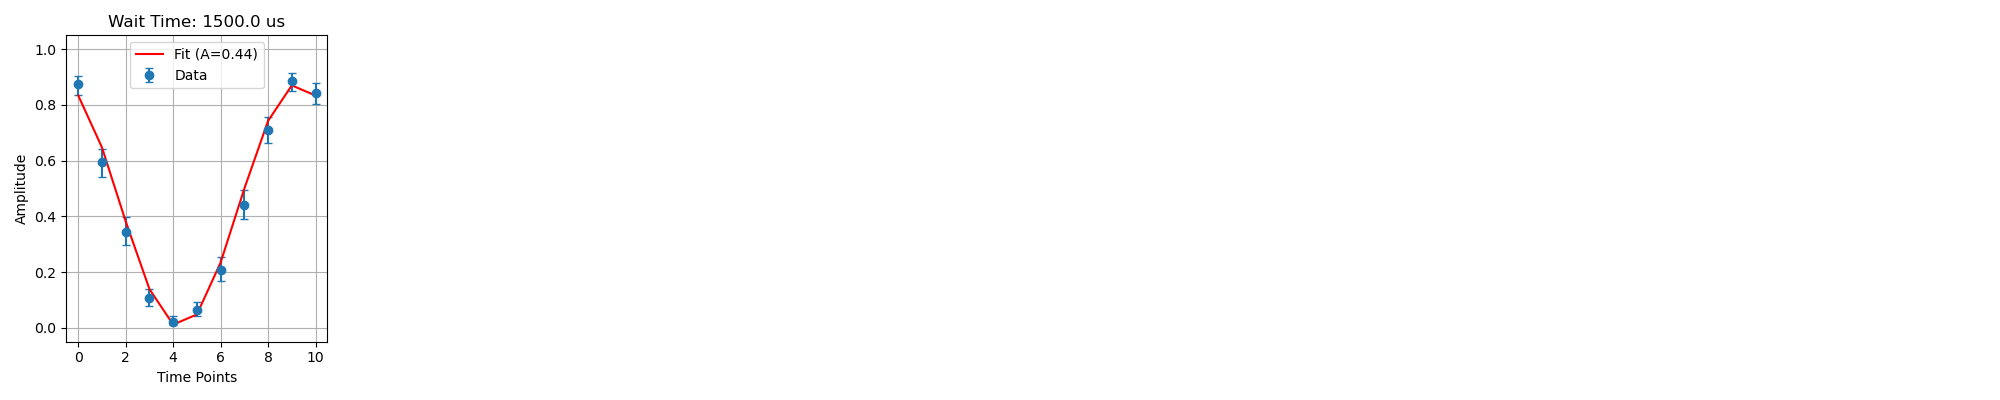


Fitted Results (Lists):
Wait Time: 1500.0 us
  Params (A, phi, offset) = 0.436, 2.692, 0.441
  Amplitude (2*|A|) = 0.873 ± 0.023
  Phase = 2.692 ± 0.042


In [183]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi/10 * t - phi - np.pi) + offset

def fit_sine_curve(ket_data, lower_error, upper_error):
    if len(ket_data) == 5:
        t = 2*np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid))/2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [0.44, np.pi, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0, 0], [0.5, 2*np.pi*0.99, 1])
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []
    
    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]
        
        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )

def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]
        
        t = np.arange(len(kd))
        ax = axes[i]
        ax.errorbar(
            t,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )
        
        if wt in fit_wait_times_list:
            # NOTE: keeping your original indexing approach unchanged
            j = fit_wait_times_list[::-1].index(wt)
            A, phi, offset = fit_params_list[::-1][i]
            if A is not None:
                fit_curve = sine_function(t, A, phi, offset)
                ax.plot(t, fit_curve, color='red', label=f'Fit (A={A:.2f})')

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Time Points')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()
    
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.savefig('laser_noise_phase_scans.png', dpi=300)
    plt.show()

# --------------------------------------------------------------------
# ONLY PLUMBING CHANGE:
# Use Cell 2 outputs: processed_wait_times, ket_data_list, ...
# --------------------------------------------------------------------
wait_time_list_for_fit = processed_wait_times

(
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results (Lists):")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]
    print(f"Wait Time: {wt} us")
    print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
    print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
    print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")


# Data Analysis 2

In [455]:
import os
import re
import ast
from datetime import datetime

folder_path = r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_bussed_ramsey_calibration_data"

pattern = re.compile(
    r"Ramsey_experiment_\[0,\s*4,\s*-2\]_(\d+)_us_(\d{8})_(\d{4})"
)

# 3pts [0, 4, 1]
start_datetime = datetime(2026, 2, 12, 13, 0)  
end_datetime = datetime(2026, 2, 12, 13, 19)

# 5pts [0, 4, 1]
# start_datetime = datetime(2026, 2, 12, 11, 39)  
# end_datetime = datetime(2026, 2, 12, 12, 18)


# 3pts [0, 4, -2]
start_datetime = datetime(2026, 2, 12, 14, 30)  
end_datetime = datetime(2026, 2, 12, 16, 50)

# 3pts [0, 4, 1]
start_datetime = datetime(2026, 2, 13, 14, 30)  
end_datetime = datetime(2026, 2, 15, 14, 50)

# 3pts [0, 4, 1]
start_datetime = datetime(2026, 2, 13, 15, 0)  
end_datetime = datetime(2026, 2, 13, 15, 20)

# 3pts [0, 4, -2]
start_datetime = datetime(2026, 2, 13, 15, 20)  
end_datetime = datetime(2026, 2, 13, 16, 50)

row1_all = []
row2_all = []
row3_all = []
row4_all = []
metadata = []

for filename in os.listdir(folder_path):
    
    match = pattern.match(filename)
    if match:
        
        full_path = os.path.join(folder_path, filename)

        # Get file modification time
        mod_timestamp = os.path.getmtime(full_path)
        mod_datetime = datetime.fromtimestamp(mod_timestamp)

        # 🔹 Only keep files after cutoff
        if mod_datetime <= start_datetime:
            continue
        if mod_datetime >= end_datetime:
            continue
        
        with open(full_path, "r") as f:
            lines = f.readlines()
            
            row1 = ast.literal_eval(lines[0].strip())
            row2 = ast.literal_eval(lines[1].strip())
            row3 = ast.literal_eval(lines[2].strip())
            row4 = ast.literal_eval(lines[3].strip())
        
        row1_all.append(row1)
        row2_all.append(row2)
        row3_all.append(row3)
        row4_all.append(row4)
        
        metadata.append({
            "params": [0, 4, 1],
            "wait_time_us": int(match.group(1)),
            "date": match.group(2),
            "time": match.group(3),
            "modified_time": mod_datetime,
            "filename": filename
        })

print(f"Loaded {len(row1_all)} files after {end_datetime}.")


Loaded 10 files after 2026-02-13 16:50:00.


In [456]:
f1_first = []
f1_second = []
for i in row1_all:
    f1_first.append(i[1])
    f1_second.append(i[2])

# Combine everything so sorting keeps alignment
combined = list(zip(metadata, f1_first, f1_second))

# Sort by file modification time
combined.sort(key=lambda x: x[0]["modified_time"])

# Unpack back
metadata_sorted, f1_first_sorted, f1_second_sorted = zip(*combined)

# Extract time axis
time_axis = [m["modified_time"] for m in metadata_sorted]


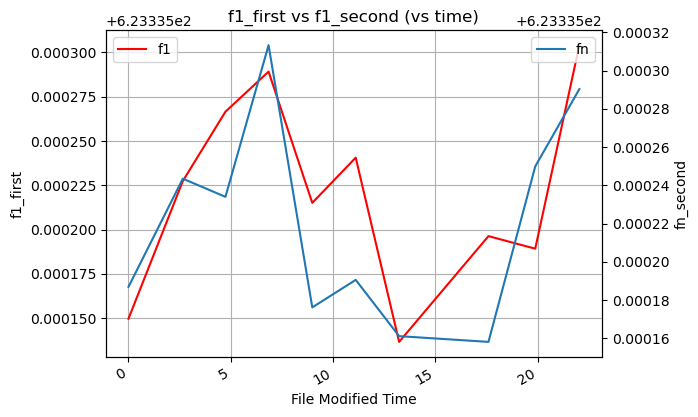

In [457]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()

# Left axis

t0 = time_axis[0]
time_minutes = [(t - t0).total_seconds()/60 for t in time_axis]

ax1.plot(time_minutes, f1_first_sorted,'r-', label = 'f1')
ax1.set_ylabel("f1_first")
ax1.set_xlabel("File Modified Time")
ax1.grid()
plt.legend()
# Right axis
ax2 = ax1.twinx()
ax2.plot(time_minutes, f1_second_sorted, label = 'fn')
ax2.set_ylabel("fn_second")

plt.title("f1_first vs f1_second (vs time)")
plt.legend()
fig.autofmt_xdate()  # makes datetime readable
plt.show()


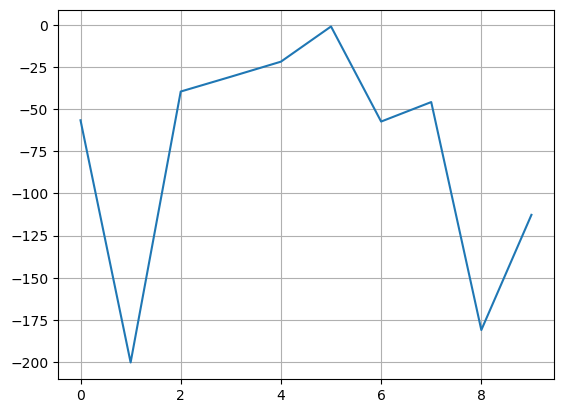

In [458]:
plt.figure()
plt.plot((np.array(det_first))*1e6)
plt.grid()
plt.show()

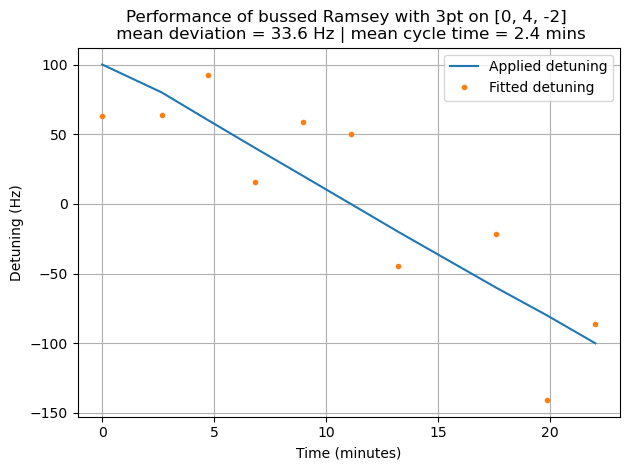

In [459]:
det_first = []
det_second = []
for i in row4_all:
    det_first.append(i[1])
    det_second.append(i[2])

actual_det = list(np.array([-100, -80, -60, -100, -80, -60, -40, -20, 0]) * -1e-6 - 83e-6)#+ list(np.array([20, 40, 60, 80, 100, -100, -80, -60, -40, -20, 0, 20, -100, -80, -60, -100, -80, -60, -40, -20, 0, 20, 40, 60,])*-1e-6 -83e-6)

actual_det =  list(np.array([-100, -80, -60, -40, -20, 0, 20]) * -1e-6 - 83e-6) # 3pts
# actual_det = list(np.array([-100, -80, -60, -100, -80, -60, -40, -20, 0]) * -1e-6 - 83e-6) #5pts

actual_det =  list(np.array([-60, -40, -20, 0, 20, 40, 60, 80, 100])* -1e-6 +26e-6) + list(np.array([-30, -10, 10, 30, 50, 70]) * -1e-6 +34e-6) # 3pts
# actual_det = list(np.array([-100, -80, -60, -100, -80, -60, -40, -20, 0]) * -1e-6 - 83e-6) #5pts
actual_det = list(np.array([-30, -10, 10, 30, 50, 70, 90, 110]) * -1e-6 +35e-6) # 3pts

actual_det = list(np.array([-100, -80, -60, -40, -20, 0, 20, 60, 80, 100]) * -1e-6)[:]

combined = list(zip(metadata, det_second, actual_det))
combined.sort(key=lambda x: x[0]["modified_time"])

metadata_sorted, det_second_sorted, actual_det_sorted = zip(*combined)

time_axis = [m["modified_time"] for m in metadata_sorted]

t0 = time_axis[0]
time_minutes = [(t - t0).total_seconds()/60 for t in time_axis]

plt.figure()
plt.plot(time_minutes, np.array(actual_det_sorted)*1e6, '-', label='Applied detuning')
plt.plot(time_minutes, np.array(det_second_sorted)*1e6, '.', label='Fitted detuning')

plt.xlabel("Time (minutes)")
plt.ylabel("Detuning (Hz)")
plt.title(f'Performance of bussed Ramsey with 3pt on [0, 4, -2] \n mean deviation = {np.round(np.mean(np.abs((np.array(det_second[:])- actual_det[:])*1e6)), 2)} Hz | mean cycle time = {np.round(np.mean(np.diff(time_minutes)),1)} mins')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [310]:
print(np.mean(np.abs((np.array(det_second[:])- actual_det[:])*1e6)))

2.1977861510859915


In [129]:
print(np.mean(np.diff(time_minutes)))

4.20238835625
